# Diffusion-map eigenvalue decay — how many components does this graph actually need?

`sim_recon_target='diffusion'` compresses each cell's full affinity-graph row into a
small `n_eigs`-dim diffusion coordinate. We've been guessing at `n_eigs` (10, then 128,
then 512) without measuring the one thing that actually determines whether a given
`n_eigs` is "enough": how fast this specific graph's eigenvalue spectrum decays.

If the spectrum drops off steeply and flattens near zero well before `num_prototypes`,
a moderate `n_eigs` captures nearly everything `full` mode would, cheaply. If it decays
slowly, `diffusion` is throwing away real structure no matter how large `n_eigs` gets,
and `full` (+ column-subsampling for speed) is the safer match to SEACells-level
fidelity. This notebook answers that empirically instead of guessing.

Uses the exact same construction as `_compute_sim_recon_diffusion_targets`
(`trainers/scproto.py`): symmetric-normalize the affinity graph, `eigsh`, drop the
trivial leading eigenvector. Run **once**, outside training — this is a diagnostic,
not something that needs to be fast.

## Setup

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!pip install -q scarches SEACells faiss-cpu scib-metrics

In [14]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


## Config

In [15]:
from interpretable_ssl.datasets.dataset_configs import DATASETS
from interpretable_ssl.augmenters.graph_generator import generate_affinity
import scanpy as sc
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import time
import glob
import pickle
import matplotlib.pyplot as plt

DS_ID = 's28nsc'
AFFINITY = 'arbf'
K_NEIGHBORS = 50  # default in configs/defaults.py — must match what real training used

# Quick probe first (cheap, sanity-checks everything below before committing to the
# expensive deep probe). Deep probe should comfortably clear num_prototypes (800 for
# this dataset) so the decay curve is visible past the point that actually matters.
QUICK_K = 200
DEEP_K = 900

## Load the affinity graph directly — no trainer, no model, no GPU

`run_mc_task(..., load_umap=True)` still builds the full scpoli model (needed for
`MultiCropsDataset`'s condition encoders) and runs the whole eval_task1/2/3 suite
afterward — real work, not just a checkpoint reload, and `build_model()`
(`trainers/scproto.py`) hardcodes `.cuda()` regardless of `device`, so it also
can't run on a CPU-only runtime. None of that is needed here — this notebook only
ever touches the affinity graph itself. So: read the AnnData directly, reuse the
affinity `.pkl` real training already cached to disk if it exists (instant), and
only fall back to computing it fresh (plain CPU: PCA + SEACells' adaptive-bandwidth
kernel, `augmenters/graph_generator.py`) if no cached copy is found.

In [16]:
ds_cfg = DATASETS[DS_ID]
num_prototypes = ds_cfg['num_prototypes']
print(f"num_prototypes (K) = {num_prototypes}  (from DATASETS config — no model needed)")

ad = sc.read_h5ad(ds_cfg['path'])
print(ad)

graph_dir = os.path.join(os.environ['CODE_DIR'], 'graphs')
# Leading "_" before AFFINITY matters: 'arbf' is also a substring of 'iarbf'/'sarbf'
# (other affinity_type variants in this codebase) — without it we could silently
# load the wrong cached graph.
candidates = glob.glob(os.path.join(graph_dir, f'affinity_*{DS_ID}*_{AFFINITY}*.pkl'))
# run_graph_generator (adata_augmenter.py) also writes a "<save_path>.inputs.pkl"
# config file (a pickled args tuple, not an affinity matrix) — it also ends in
# ".pkl" so the glob above matches it too. Exclude it or we may load the wrong file.
candidates = [c for c in candidates if not c.endswith('.inputs.pkl')]
print(f'cached affinity candidates: {candidates}')

if candidates:
    with open(candidates[0], 'rb') as f:
        affinity = pickle.load(f)
    print(f'loaded cached affinity from {candidates[0]}')
else:
    print('no cached affinity found — computing fresh (CPU only, no model/GPU)')
    if 'X_pca' not in ad.obsm:
        sc.tl.pca(ad, n_comps=50)
    affinity = generate_affinity(ad, k=K_NEIGHBORS, bk=ds_cfg['batch_key'], affinity_type=AFFINITY)

num_prototypes (K) = 800  (from DATASETS config — no model needed)
AnnData object with n_obs × n_vars = 58423 × 960
    obs: 'section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche'
    uns: 'EMT_niche_colors', 'celltypes_colors', 'fibroblast_subclusters_colors', 'log1p', 'niches_2D_colors', 'niches_3D_colors', 'pca'
    obsm: 'X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial'
    varm: 'PCs'
    layers: 'SCT', 'counts', None (.X)
cached affinity candidates: ['/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_s28nsc58423_ncomp50_kneighbors50_arbf.pkl', '/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_ss28nsc28804_ncomp50_kneighbors50_arbf.pkl', '/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_s28nsc58423_ncomp50_kneighbors50_arbf_custom.pkl', '/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_s28nsc58423

## Build the normalized affinity matrix (same as `_compute_sim_recon_diffusion_targets`)

In [17]:
A = sp.csr_matrix(affinity)
N = A.shape[0]
mean_degree = A.getnnz(axis=1).mean()
print(f'N cells = {N}')
print(f'mean degree (nonzero entries/row) = {mean_degree:.1f}  ->  sparsity = {100*(1 - mean_degree/N):.2f}% zero')

A_sym = (A + A.T) / 2
d = np.array(A_sym.sum(axis=1)).ravel()
D_inv_sqrt = sp.diags(1.0 / np.sqrt(d + 1e-8))
L_sym = D_inv_sqrt @ A_sym @ D_inv_sqrt

N cells = 58423
mean degree (nonzero entries/row) = 74.5  ->  sparsity = 99.87% zero


## Quick probe (sanity check before the expensive run)

In [18]:
t0 = time.time()
vals_q, _ = eigsh(L_sym, k=QUICK_K, which='LM', tol=1e-2)
print(f'eigsh(k={QUICK_K}) took {time.time() - t0:.1f}s')

vals_q = np.sort(vals_q)[::-1][1:]  # descending, drop trivial leading eigenvalue (~1)
print(f'top 10 eigenvalues after dropping trivial one: {np.round(vals_q[:10], 4)}')
print(f'eigenvalues 190-199 (near the k={QUICK_K} cutoff): {np.round(vals_q[-10:], 4)}')

eigsh(k=200) took 101.6s
top 10 eigenvalues after dropping trivial one: [1.   0.99 0.98 0.97 0.97 0.97 0.96 0.96 0.95 0.94]
eigenvalues 190-199 (near the k=200 cutoff): [0.7  0.7  0.7  0.7  0.7  0.7  0.7  0.69 0.69 0.69]


## Deep probe — the real answer

This is the expensive one. Timing it directly tells you whether `eigsh` at a
trustworthy `n_eigs` is actually still cheap relative to fixing `full` mode instead.

In [19]:
t0 = time.time()
vals, vecs = eigsh(L_sym, k=DEEP_K, which='LM', tol=1e-2)
eigsh_seconds = time.time() - t0
print(f'eigsh(k={DEEP_K}) took {eigsh_seconds:.1f}s ({eigsh_seconds/60:.1f} min)')

order = np.argsort(-vals)
vals_sorted = vals[order][1:]  # descending, drop trivial leading eigenvalue

eigsh(k=900) took 972.8s (16.2 min)


## Scree plot — raw eigenvalue magnitude vs. rank

Where this flattens near zero is roughly where additional eigenvectors stop
encoding real graph structure and start encoding noise.

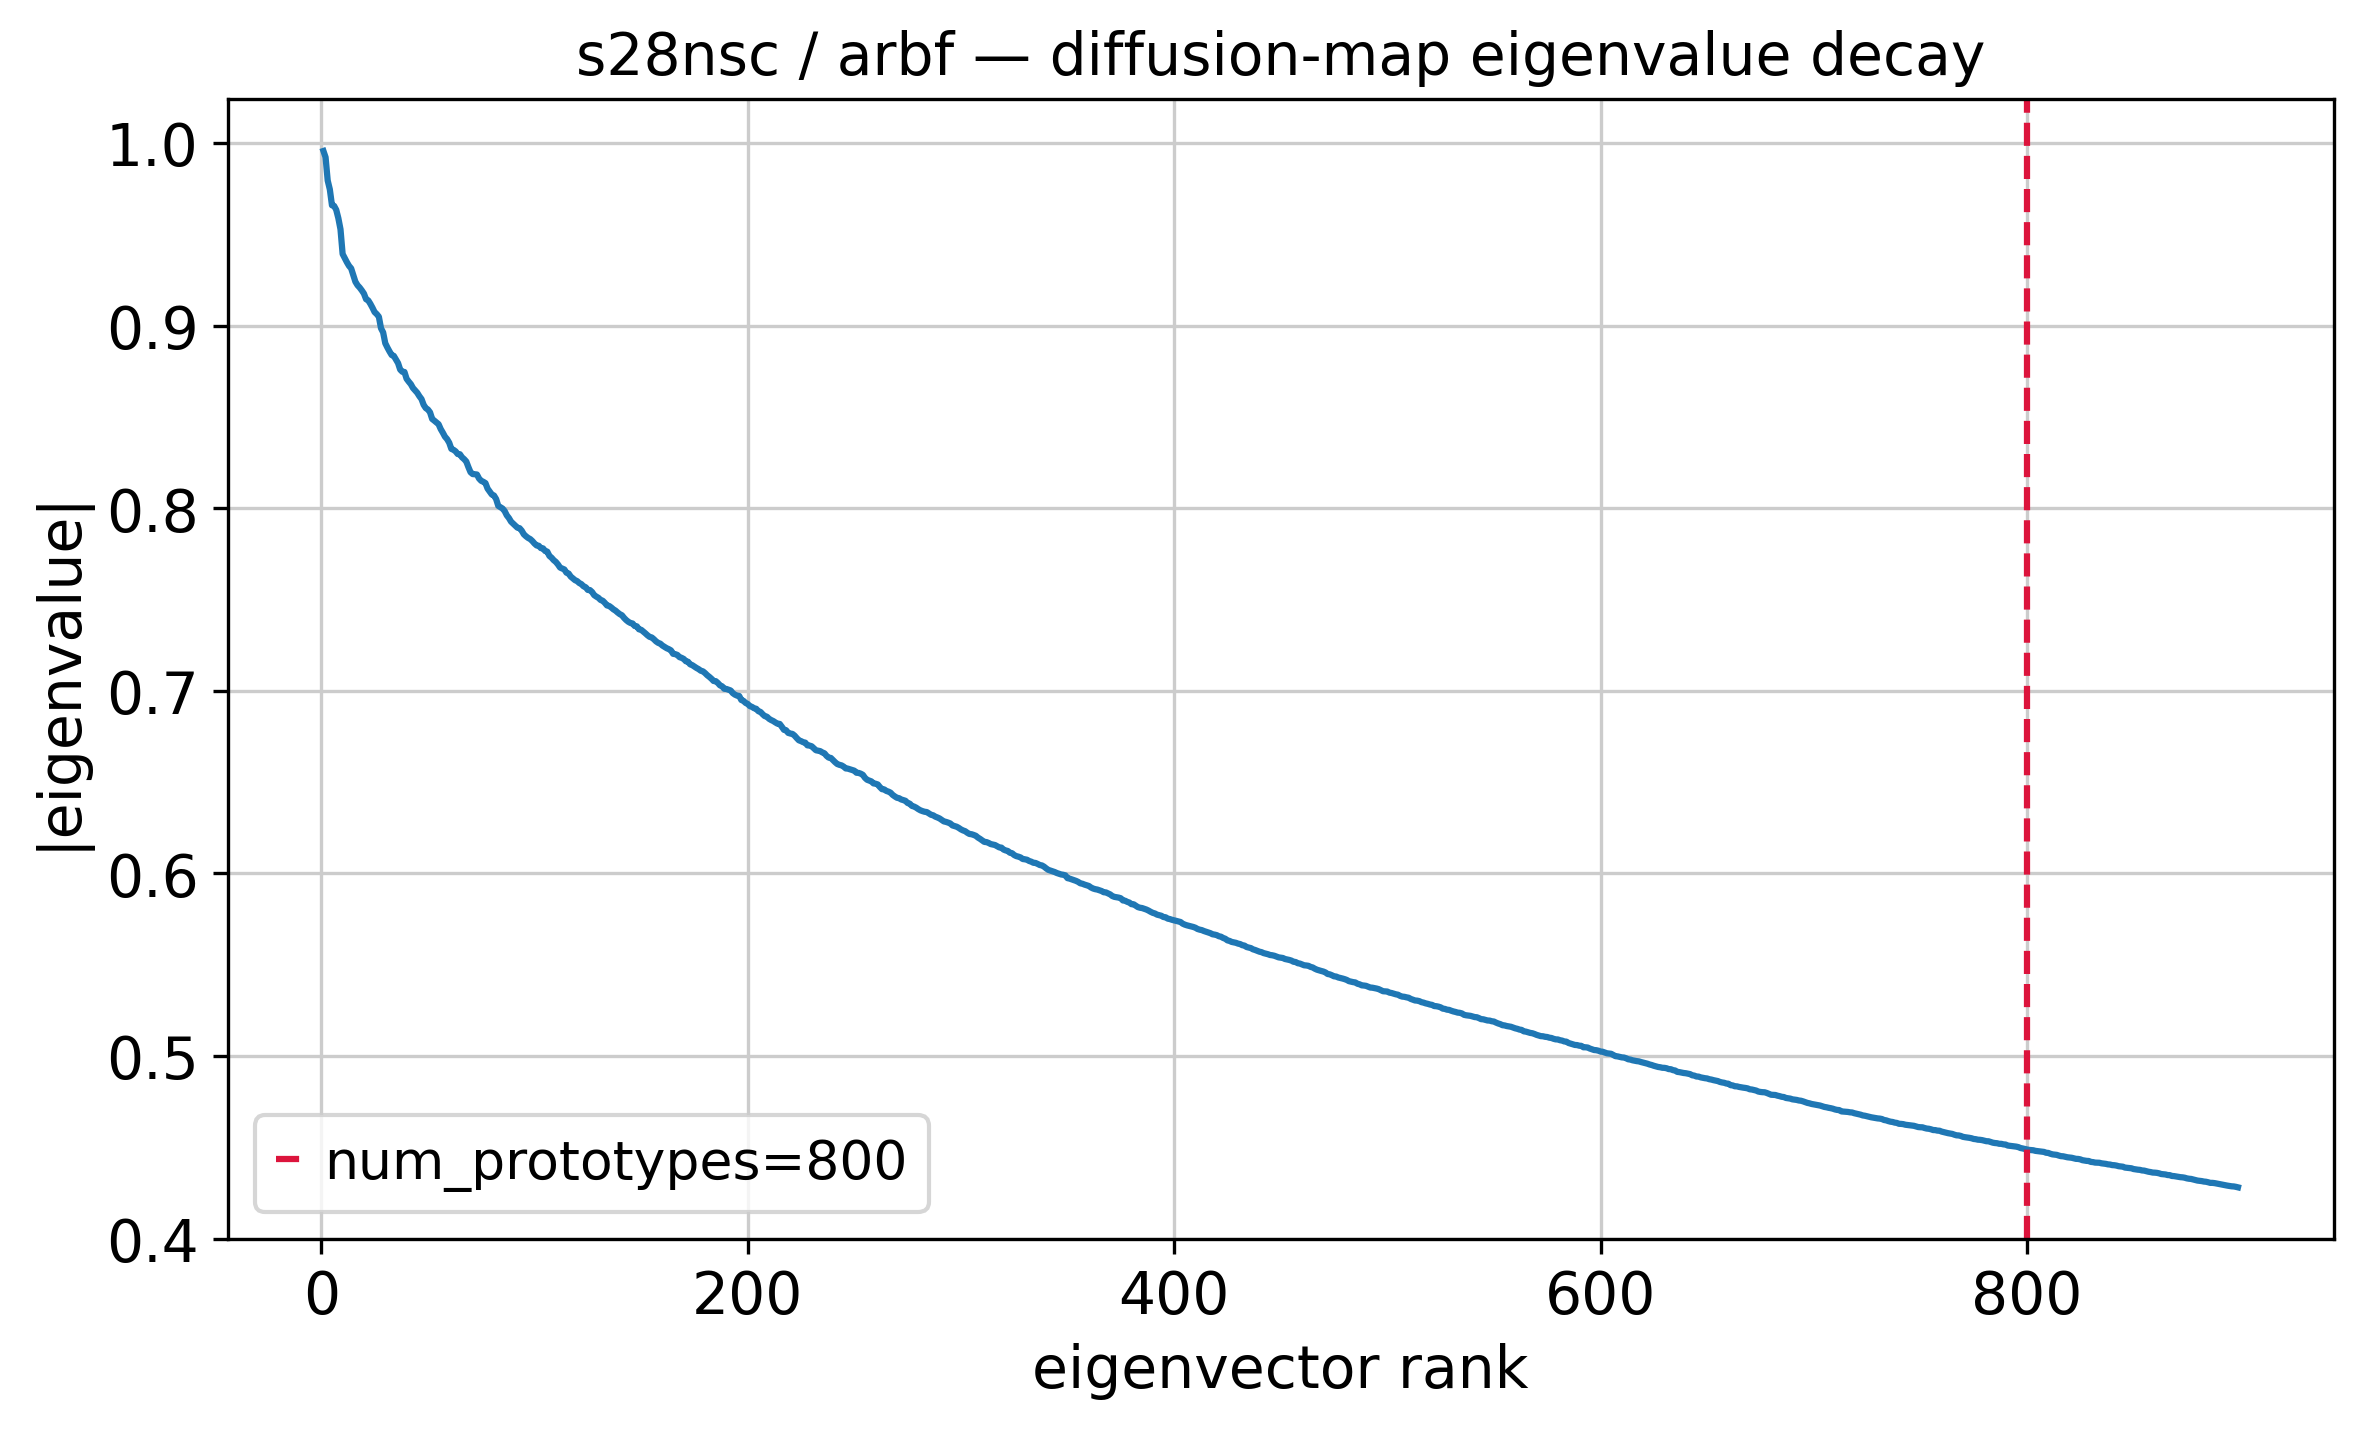

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(vals_sorted) + 1), np.abs(vals_sorted), lw=1.5)
ax.axvline(num_prototypes, color='crimson', ls='--', label=f'num_prototypes={num_prototypes}')
ax.set_xlabel('eigenvector rank')
ax.set_ylabel('|eigenvalue|')
ax.set_title(f'{DS_ID} / {AFFINITY} — diffusion-map eigenvalue decay')
ax.legend()
plt.show()

## Cumulative "energy" — the practical n_eigs picker

Analogous to explained-variance-ratio in PCA: fraction of total squared-eigenvalue
mass captured by the top-k eigenvectors. Read off where this crosses 90/95/99% —
that's your evidence-based `n_eigs`, instead of a guess.

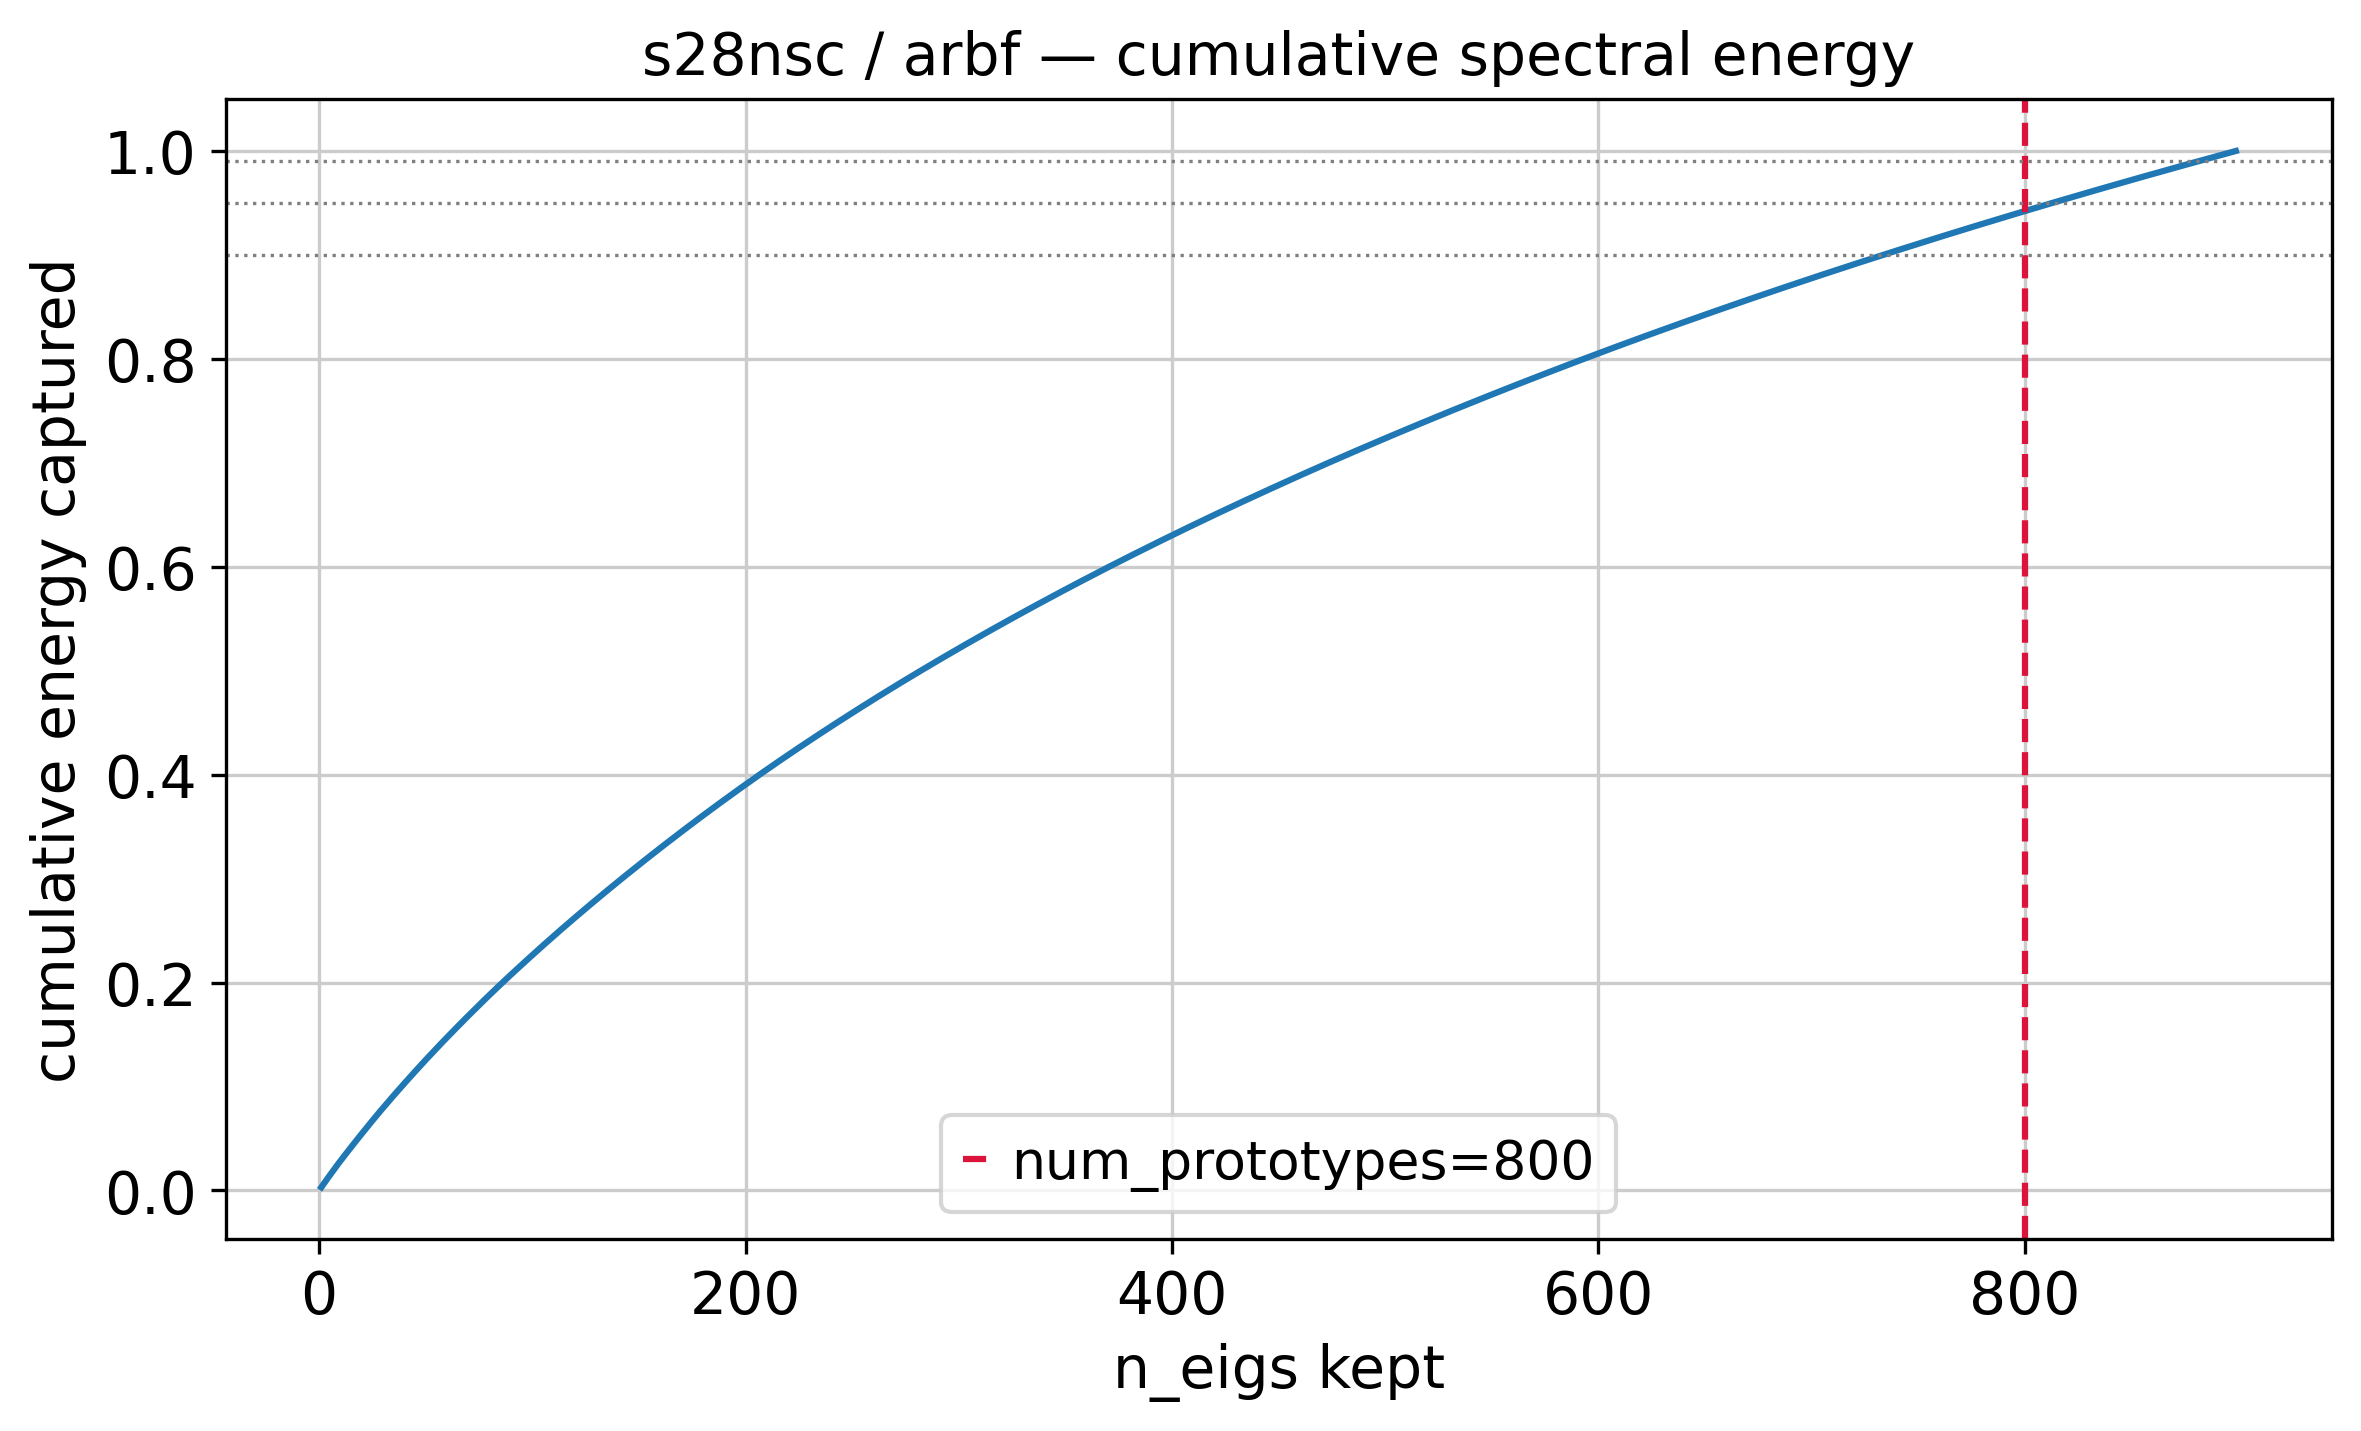

n_eigs needed to reach:
  90%: n_eigs=734  (within K (not wasted))
  95%: n_eigs=813  (EXCEEDS K — diffusion capped below this fidelity)
  99%: n_eigs=882  (EXCEEDS K — diffusion capped below this fidelity)


In [21]:
energy = vals_sorted ** 2
cum_energy = np.cumsum(energy) / energy.sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(cum_energy) + 1), cum_energy, lw=1.5)
ax.axvline(num_prototypes, color='crimson', ls='--', label=f'num_prototypes={num_prototypes}')
for frac in (0.90, 0.95, 0.99):
    ax.axhline(frac, color='gray', ls=':', lw=0.8)
ax.set_xlabel('n_eigs kept')
ax.set_ylabel('cumulative energy captured')
ax.set_title(f'{DS_ID} / {AFFINITY} — cumulative spectral energy')
ax.legend()
plt.show()

print('n_eigs needed to reach:')
for frac in (0.90, 0.95, 0.99):
    k_needed = int(np.searchsorted(cum_energy, frac) + 1)
    verdict = 'within K (not wasted)' if k_needed <= num_prototypes else 'EXCEEDS K — diffusion capped below this fidelity'
    print(f'  {int(frac*100)}%: n_eigs={k_needed}  ({verdict})')

## Reading the result

- If 90-95% energy is reached well **below** `num_prototypes`, `diffusion` at a modest
  `n_eigs` is capturing nearly everything the K-prototype bottleneck could use anyway —
  `diffusion` is a reasonable, cheap choice.
- If it takes close to or more than `num_prototypes` eigenvectors to reach 90%, the
  graph's real structure is spread out enough that any `n_eigs` you'd consider is
  discarding a meaningful amount — `full` (+ column-subsampling for speed) is the
  safer match to SEACells-level fidelity.
- Check `eigsh_seconds` above either way: if the deep probe took a long time, that's
  the real cost of trusting a large `n_eigs`, independent of what the curve shows.